In [33]:
# Import the three libraries the tutorial uses.
import mesa          # the agent-based modeling framework itself
import numpy as np   # math/array library; "as np" lets us type np instead of numpy
import pandas as pd  # data tables for analysis later; "as pd" is the standard shorthand

# Print the Mesa version so we confirm the notebook is using our 3.5.1 install
print("Mesa version:", mesa.__version__)

Mesa version: 3.5.1


In [34]:
# Define our first agent. It inherits from mesa.Agent, which gives it
# a unique ID, a link to the model, and grid-placement ability for free.
class MoneyAgent(mesa.Agent):

    # The constructor: runs once when each agent is created.
    # "self" = this particular agent. "model" = the world it lives in.
    def __init__(self, model):
        # REQUIRED FIRST LINE in Mesa 3.x: hand control to the parent
        # Agent class so Mesa can register this agent and assign its ID.
        super().__init__(model)

        # Now our own attribute: every agent starts with 1 unit of wealth.
        self.wealth = 1

    # The behavior: the model calls this once per step for every agent.
    def step(self):
        # If this agent has no money, it can't give any away — stop here.
        if self.wealth == 0:
            return  # "return" exits the method early, skipping the rest

        # Pick a random OTHER agent from everyone in the model.
        # self.model.agents is Mesa's built-in set of all agents.
        other_agent = self.random.choice(self.model.agents)

        # Hand one coin over: they gain 1, we lose 1.
        if other_agent is not None:
            other_agent.wealth += 1   # += means "add 1 to existing value"
            self.wealth -= 1          # -= means "subtract 1"

In [35]:
# The Model is the whole simulation world. It inherits from mesa.Model.
class MoneyModel(mesa.Model):

    # Constructor. "n" is how many agents we want; "seed" makes runs reproducible.
    def __init__(self, n, seed=None):
        # REQUIRED: let the parent Model class set itself up first.
        # Passing seed makes the random number generator repeatable.
        super().__init__(seed=seed)

        # Store the number of agents as an attribute, in case we want it later.
        self.num_agents = n

        # Create n agents in one line. Mesa 3.x's create_agents builds them,
        # runs each one's __init__, and registers them in self.agents for us.
        MoneyAgent.create_agents(model=self, n=n)

    # One tick of the simulation.
    def step(self):
        # Activate every agent's step() once, in a fresh random order each tick.
        self.agents.shuffle_do("step")

In [36]:
# Create a model with 10 agents.
model = MoneyModel(10)

# Run the simulation for 20 steps (20 ticks of time).
for i in range(20):       # range(20) gives 0,1,2...19 — loops 20 times
    model.step()          # each loop = one tick where all agents act

# Pull every agent's wealth into a list so we can see the result.
# This reads each agent's .wealth across the whole agent set.
wealths = [agent.wealth for agent in model.agents]
print("Wealth of each agent after 20 steps:", wealths)

Wealth of each agent after 20 steps: [0, 0, 0, 0, 3, 0, 1, 2, 3, 1]


In [37]:
class MoneyAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.wealth = 1

    # NEW: move to a random neighboring cell.
    def move(self):
        # Ask the grid: what cells are adjacent to where I am right now?
        # self.pos is my current (x, y), auto-set when I was placed.
        # moore=True  -> all 8 surrounding cells count (diagonals included)
        # include_center=False -> don't count my own cell as an option
        possible_steps = self.model.grid.get_neighborhood(
            self.pos,
            moore=True,
            include_center=False,
        )
        # Pick one of those neighbor cells at random (self.random = my own RNG).
        new_position = self.random.choice(possible_steps)
        # Physically relocate me on the grid to that cell.
        self.model.grid.move_agent(self, new_position)

    # NEW: give a coin only to someone sharing my cell.
    def give_money(self):
        # get_cell_list_contents asks "who else is standing on my cell?"
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        # Remove myself from that list so I don't give money to myself.
        cellmates = [c for c in cellmates if c is not self]
        # If anyone else is here and I have money, hand one coin over.
        if len(cellmates) > 0 and self.wealth > 0:
            other = self.random.choice(cellmates)
            other.wealth += 1
            self.wealth -= 1

    def step(self):
        # Each tick: first move, then maybe give money to a cellmate.
        self.move()
        self.give_money()

In [38]:
class MoneyModel(mesa.Model):
    # NEW parameters: width and height of the building grid.
    def __init__(self, n, width, height, seed=None):
        super().__init__(seed=seed)
        self.num_agents = n

        # Create the grid. MultiGrid = multiple agents allowed per cell
        # (the classic, stable grid class). torus=False = edges are hard
        # walls, no wrap-around (correct for a physical building).
        self.grid = mesa.space.MultiGrid(width, height, torus=False)

        # Build the agents (same as before).
        agents = MoneyAgent.create_agents(model=self, n=n)

        # NEW: drop each agent onto a random cell.
        for agent in agents:
            # Pick a random x within the grid width, random y within height.
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(agent, (x, y))

    def step(self):
        self.agents.shuffle_do("step")

In [39]:
# 50 agents on a 10x10 grid.
model = MoneyModel(50, 10, 10)

# Run 30 ticks.
for i in range(30):
    model.step()

# Print where the first 5 agents ended up, to prove they have positions.
for agent in list(model.agents)[:5]:
    print(f"Agent at position {agent.pos} has wealth {agent.wealth}")

Agent at position (5, 8) has wealth 0
Agent at position (9, 1) has wealth 1
Agent at position (4, 1) has wealth 1
Agent at position (4, 1) has wealth 0
Agent at position (0, 4) has wealth 1


In [40]:
# A standalone function the DataCollector will call once per step.
# It receives the model and returns a single number: total wealth in the system.
# (In your fire sim, the equivalent will be "number of agents evacuated".)
def compute_total_wealth(model):
    # Sum the .wealth of every agent in the model.
    total = sum(agent.wealth for agent in model.agents)
    return total

In [41]:
class MoneyModel(mesa.Model):
    def __init__(self, n, width, height, seed=None):
        super().__init__(seed=seed)
        self.num_agents = n
        self.grid = mesa.space.MultiGrid(width, height, torus=False)

        agents = MoneyAgent.create_agents(model=self, n=n)
        for agent in agents:
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(agent, (x, y))

        # NEW: set up the recorder.
        # model_reporters: name -> function (called with the model each step)
        # agent_reporters: name -> attribute string (grabbed from each agent)
        self.datacollector = mesa.DataCollector(
            model_reporters={"TotalWealth": compute_total_wealth},
            agent_reporters={"Wealth": "wealth"},
        )

    def step(self):
        # Record the current state BEFORE agents act this tick.
        # (Collecting first captures the starting point at step 0.)
        self.datacollector.collect(self)
        # Then advance all agents.
        self.agents.shuffle_do("step")

In [42]:
# Run a fresh model.
model = MoneyModel(50, 10, 10)
for i in range(100):
    model.step()

# Pull the model-level time series into a pandas DataFrame (a data table).
# Each row = one step; the column is TotalWealth.
model_data = model.datacollector.get_model_vars_dataframe()
print(model_data.head())   # .head() shows the first 5 rows

# Pull the agent-level data too (much bigger: every agent, every step).
agent_data = model.datacollector.get_agent_vars_dataframe()
print(agent_data.head())

   TotalWealth
0           50
1           50
2           50
3           50
4           50
              Wealth
Step AgentID        
1.0  1             1
     2             1
     3             1
     4             1
     5             1


Matplotlib is building the font cache; this may take a moment.


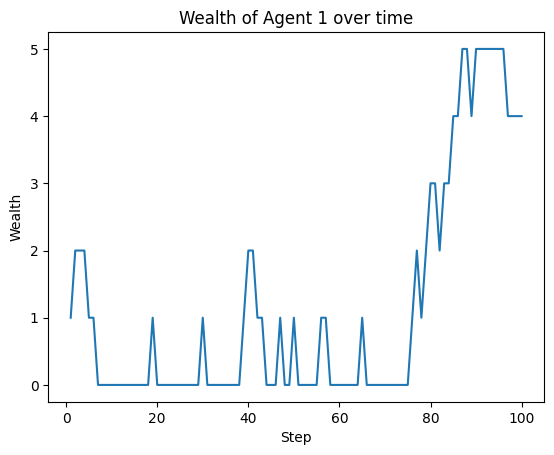

In [43]:
# Import matplotlib's plotting interface. "plt" is the universal shorthand.
import matplotlib.pyplot as plt

# From the agent data, pull out just ONE agent's history over all steps.
# .xs() = "cross-section": grab all rows where AgentID == 1.
# level="AgentID" tells pandas which index level to filter on.
one_agent_wealth = agent_data.xs(1, level="AgentID")

# Plot it. The x-axis is the Step index, the y-axis is the Wealth column.
one_agent_wealth.plot(
    title="Wealth of Agent 1 over time",  # chart title
    xlabel="Step",                         # x-axis label
    ylabel="Wealth",                       # y-axis label
    legend=False,                          # hide the legend (only one line)
)

# Display the chart. In a notebook, plots often show automatically,
# but calling plt.show() makes it explicit and reliable.
plt.show()